In [1]:
#undef __noinline__

# Ray Tracing"

This notebook demonstrates how ray tracing works in a very simple way.

## The Scene

We create a 1024×1024 pixel image. In front of this image, we randomly place discs. Each disc has:

    - A random color (red, green, blue),
    - A random size (radius between 20-80 pixels),
    - A random position (x, y coordinates in the image plane),
    - A random depth (z coordinate, how far in front of the image)",
    
The discs are scattered at different distances from the camera, creating a 3D scene.\n",
Below we can see how ray tracing works.

![Ray Tracing](images/ray_tracing.png)

The camera sits at the origin looking in the +Z direction. Every pixel fires
a ray parallel to Z, described only by its (ox, oy) offset from the image centre.
All rays point the same direction - much simpler than a full ray tracer.

In [2]:
#include <cstdlib>
#include <cstdio>
#include <ctime>
#include <cmath>

#define IMG  1024
#define NDISCS 15

## The Disc struct

Each disc stores colour, radius, and position. The `intersect` method answers:
*does the ray at screen offset (ox, oy) intersect this sphere, and if so, how deep?*

It works by computing the 2D distance from the ray to the sphere centre.
If that distance is less than the radius, the ray enters the sphere and we
calculate the depth `z` using the Pythagorean theorem.

In [3]:
struct Disc {
    float r, g, b;    // colour
    float cx, cy, z;  // centre in 3-D
    float radius;

    // Returns the disc's z value if the ray at (ox,oy) hits.
    __device__ float intersect(float ox, float oy, float *normal_val) const {
        float dx = ox - cx;
        float dy = oy - cy;
        float distSq = dx * dx + dy * dy;
        
        if (distSq < radius * radius)
        {
            float dz;
            float depth_sq = radius * radius - distSq;
            asm("sqrt.rn.f32 %0, %1;" : "=f"(dz) : "f"(depth_sq));
            
            *normal_val = dz / radius;
            return z;
        }
        return -1e9f;
    }
};

## The kernel

Each thread owns one pixel. It loops over every disc, calls `intersect`, and keeps track
of the ones that was hit at the greatest depth (closest to the camera).

The disc colour, scaled by the surface normal, gives simple diffuse shading.

In [4]:
__global__ void render(const Disc *discs, unsigned char *fb) {
    int col = threadIdx.x + blockIdx.x * blockDim.x;
    int row = threadIdx.y + blockIdx.y * blockDim.y;
    if (col >= IMG || row >= IMG) return;

    // Normalised ray origin in [-0.5, 0.5]
    float ox = (float)col / IMG - 0.5f;
    float oy = (float)row / IMG - 0.5f;

    float best_z = -1e9f;
    float fr = 0.f, fg = 0.f, fb_val = 0.f;

    for (int d = 0; d < NDISCS; d++) {
        float normal = 0.f; 
        // FIXED: Added &normal parameter so the function can populate the light interaction value
        float depth = discs[d].intersect(ox, oy, &normal); 
        
        if (depth > best_z) {
            best_z = depth;
            
            fr     = discs[d].r * normal;
            fg     = discs[d].g * normal; 
            fb_val = discs[d].b * normal;
        }
    }

    // Clamp the colors to a maximum of 1.0f using direct PTX hardware min instructions
    float cr, cg, cb;
    asm("min.f32 %0, %1, 1.0;" : "=f"(cr) : "f"(fr));
    asm("min.f32 %0, %1, 1.0;" : "=f"(cg) : "f"(fg));
    asm("min.f32 %0, %1, 1.0;" : "=f"(cb) : "f"(fb_val));

    // Store safely directly to the frame buffer
    int px = (row * IMG + col) * 4;
    fb[px + 0] = (unsigned char)(cr * 255.f);
    fb[px + 1] = (unsigned char)(cg * 255.f);
    fb[px + 2] = (unsigned char)(cb * 255.f);
    fb[px + 3] = 255;
}

Here we configure all variables and create the random spheres on the CPU, then copy them to the GPU.

In [5]:
unsigned char *h_fb = (unsigned char*)malloc(IMG * IMG * 4);
unsigned char *d_fb;
Disc          *d_discs;
cudaMalloc(&d_fb,    IMG * IMG * 4);
cudaMalloc(&d_discs, NDISCS * sizeof(Disc));

// Build random scene on the CPU
Disc scene[NDISCS];
srand(time(NULL));

auto rnd = [](float hi) { return hi * (float)rand() / (float)RAND_MAX; };

for (int i = 0; i < NDISCS; i++) {
    scene[i].r      = rnd(1.0f);
    scene[i].g      = rnd(1.0f);
    scene[i].b      = rnd(1.0f);
    
    scene[i].cx     = rnd(1.0f) - 0.5f;  // [-0.5, 0.5]
    scene[i].cy     = rnd(1.0f) - 0.5f;  // [-0.5, 0.5]
    scene[i].z      = rnd(1.0f) - 0.5f;  // [-0.5, 0.5]
    
    scene[i].radius = rnd(0.1f) + 0.04f; 
}

cudaMemcpy(d_discs, scene, NDISCS * sizeof(Disc), cudaMemcpyHostToDevice);

In [6]:
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "headers/stb_image_write.h"

dim3 block(16, 16);
dim3 grid(IMG / 16, IMG / 16);
render<<<grid, block>>>(d_discs, d_fb);
cudaDeviceSynchronize();

cudaMemcpy(h_fb, d_fb, IMG * IMG * 4, cudaMemcpyDeviceToHost);
stbi_write_png("images/RayTrace.png", IMG, IMG, 4, h_fb, IMG * 4);
printf("Saved RayTrace.png\n");

cudaFree(d_fb);  cudaFree(d_discs);  free(h_fb);

Saved RayTrace.png


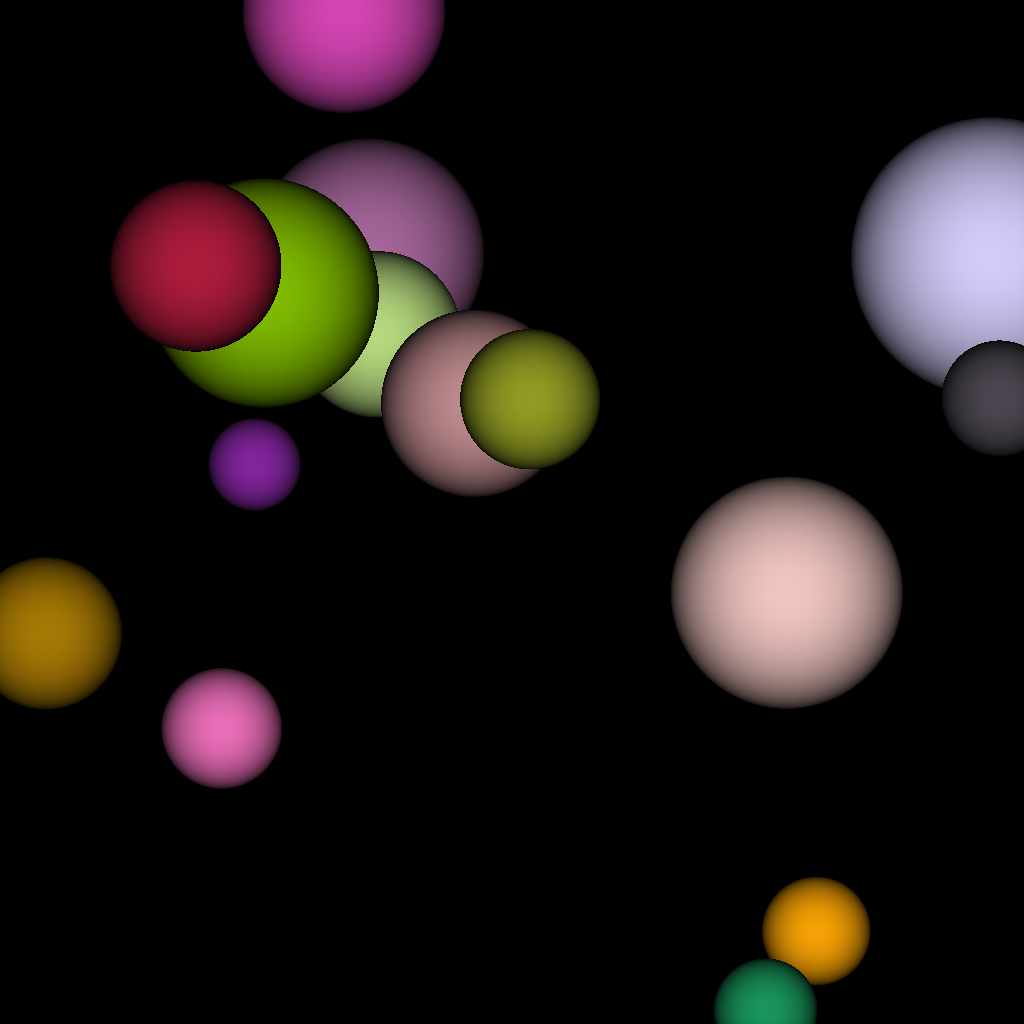

In [7]:
#include "headers/display.hpp"

im::image rt_image("images/RayTrace.png");
xcpp::display(rt_image);